# Metodologia Design Science Research (DSR)

**Etapa de Pesquisa (Peffers et al., 2007):**
### 3. Design e Desenvolvimento (Design and Development)

**Objetivo Acadêmico:** Este notebook foca na otimização da dimensionalidade do artefato. Com a inclusão dos *embeddings* do BERT, o espaço de características expandiu-se significativamente (800+ variáveis). O rigor científico exige a aplicação de técnicas de seleção de variáveis (como *ExtraTrees Importance*) para garantir a parcimônia do modelo e evitar o *Overfitting*, assegurando que o artefato final seja eficiente e interpretável, seguindo as diretrizes de Hevner et al. (2004).


# 06 - Seleção de Variáveis Avançada (ExtraTrees Importance)
Neste notebook, unificamos as features temporais, climatológicas e semânticas (BERT) e selecionamos as mais relevantes para o modelo final, reduzindo a dimensionalidade e o ruído.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel
import os

# Configurações
BASE_FEATURES = '../data/base_features_final.csv'
BASE_BERT = '../data/embeddings_bert_cardapio.csv'
SAIDA_SELECIONADA = '../data/base_features_selecionadas.csv'
TARGET = 'total_servido'

# 1. Carregamento e Unificação
df_feat = pd.read_csv(BASE_FEATURES)
df_bert = pd.read_csv(BASE_BERT)

df_feat['data'] = pd.to_datetime(df_feat['data'])
df_bert['data'] = pd.to_datetime(df_bert['data'])

# Merge (92 dias validados)
df = pd.merge(df_feat, df_bert, on='data', how='inner')
df = df.sort_values('data').reset_index(drop=True)

print(f"📦 Base Unificada: {df.shape[0]} dias e {df.shape[1]} colunas.")

📦 Base Unificada: 92 dias e 805 colunas.


In [2]:
# 2. Preparação do Treino
# Colunas que não são preditoras (texto puro ou metadados)
DROP_COLS = ['data', 'evento', 'proteina_principal', 'preparo_principal', 'proteina_vegetariana', TARGET]
# Algumas colunas de fluxo tbm não podem ser usadas (vazamento)
DROP_COLS += ['total_servido', 'reservou_e_comeu', 'reservou_e_nao_comeu', 'nao_reservou_e_comeu']

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y = df[TARGET]

# Garantir que tudo é numérico
X = X.select_dtypes(include=[np.number])

print(f"🔍 Matriz X pronta para seleção: {X.shape[1]} variáveis.")

🔍 Matriz X pronta para seleção: 796 variáveis.


🔄 Calculando importância das variáveis (isso pode demorar devido ao BERT)...


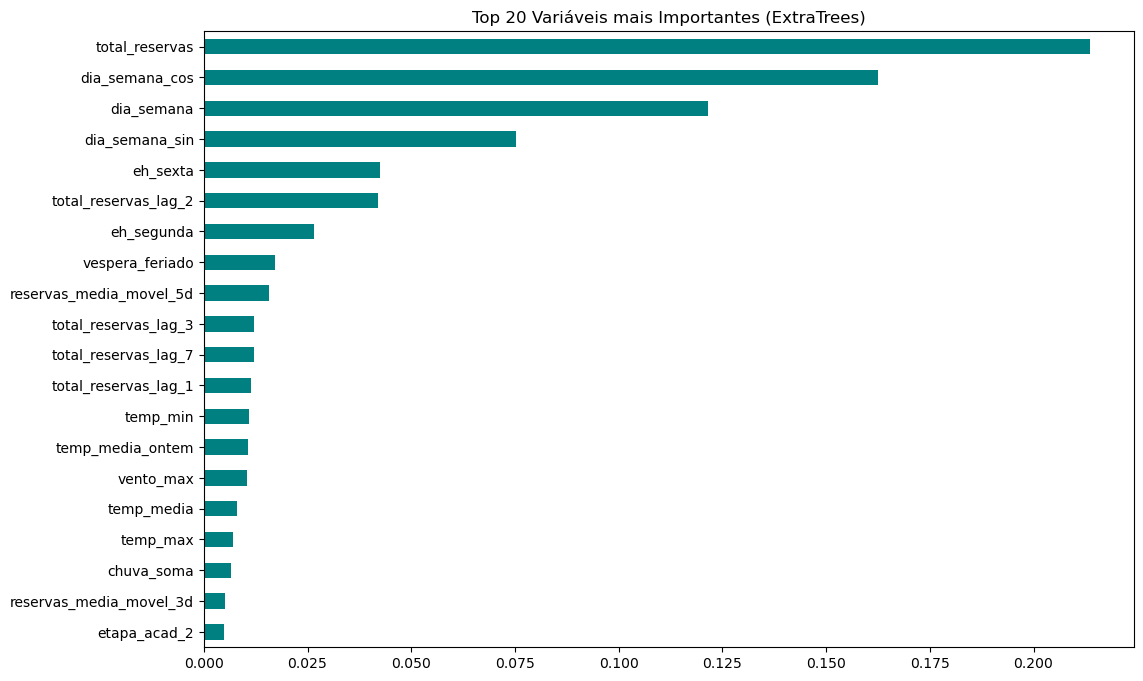

✨ Seleção concluída!
📊 Base compactada salva em: ../data/base_features_selecionadas.csv
📈 Dimensão final: (92, 52)
✔️ Principais features incluídas: ['total_reservas', 'dia_semana_cos', 'dia_semana', 'dia_semana_sin', 'eh_sexta']


In [3]:
# 3. Seleção por Importância (ExtraTrees)
print("🔄 Calculando importância das variáveis (isso pode demorar devido ao BERT)...")
model = ExtraTreesRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Obter importâncias
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visualizar Top 20
plt.figure(figsize=(12, 8))
importances.head(20).plot(kind='barh', color='teal')
plt.title("Top 20 Variáveis mais Importantes (ExtraTrees)")
plt.gca().invert_yaxis()
plt.show()

# 4. Seleção Final (Top 50 Variáveis)
# Vamos manter as 50 melhores para garantir que não percamos nuances do BERT
selected_features = importances.head(50).index.tolist()

# 5. Exportação
df_final = df[['data', TARGET] + selected_features].copy()
df_final.to_csv(SAIDA_SELECIONADA, index=False)

print(f"✨ Seleção concluída!")
print(f"📊 Base compactada salva em: {SAIDA_SELECIONADA}")
print(f"📈 Dimensão final: {df_final.shape}")
print(f"✔️ Principais features incluídas: {selected_features[:5]}")